In [2]:
import ast
import matplotlib.pyplot as plt
import pandas as pd 
from datasets import load_dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

<Axes: xlabel='job_title_short'>

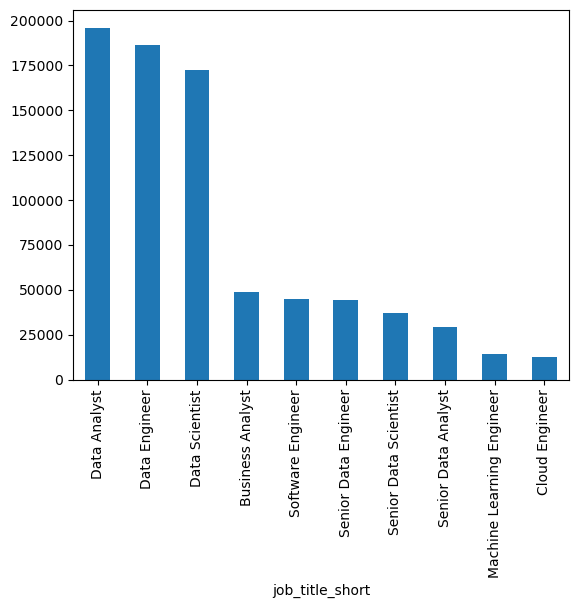

In [6]:
fig,ax =plt.subplots()
df['job_title_short'].value_counts().plot(kind='bar',ax=ax)

In [7]:
df['job_schedule_type'].value_counts().head(3)

job_schedule_type
Full-time     701727
Contractor     34793
Internship      8742
Name: count, dtype: int64

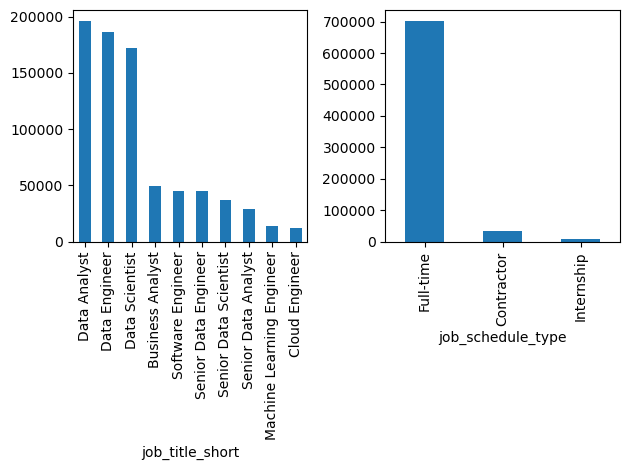

In [11]:
fig, ax=plt.subplots(1,2)
df['job_title_short'].value_counts().plot(kind='bar',ax=ax[0])
df['job_schedule_type'].value_counts().head(3).plot(kind='bar',ax=ax[1])
fig.tight_layout()

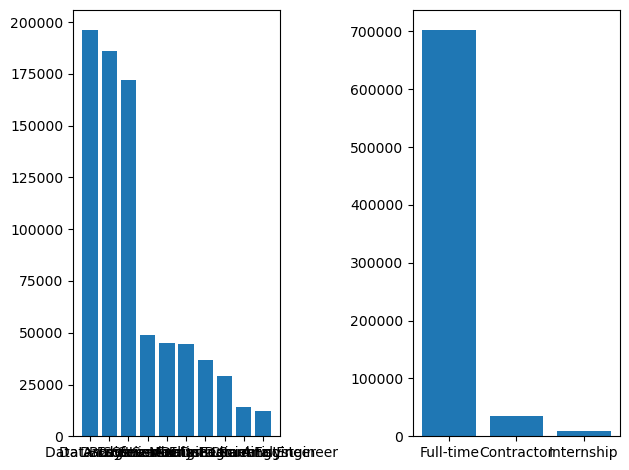

In [12]:
#matplotlib
fig, ax=plt.subplots(1,2)
ax[0].bar(df['job_title_short'].value_counts().index,df['job_title_short'].value_counts())
ax[1].bar(df['job_schedule_type'].value_counts().head(3).index,df['job_schedule_type'].value_counts().head(3))
fig.tight_layout()

In [24]:
df_skills=df.copy()
df_skills=df_skills.explode('job_skills')
skills_counts=df_skills.groupby(['job_skills','job_title_short']).size()
df_skills_counts=skills_counts.reset_index(name='skill_count')
df_skills_counts.sort_values(by='skill_count',ascending=False,inplace=True)
df_skills_counts

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


In [30]:
job_titles=['Data Scientist','Data Engineer','Data Analyst']


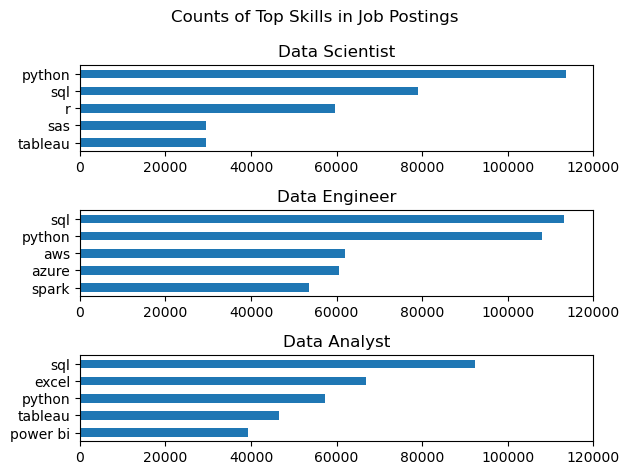

In [47]:
fig, ax = plt.subplots(3,1)
for i, job_title in enumerate(job_titles):
    df_plot=df_skills_counts[df_skills_counts['job_title_short']==job_title].head(5)
    df_plot.plot(kind='barh',x='job_skills',y='skill_count',ax=ax[i])
    ax[i].set_title(job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,120000)

#title for all
fig.suptitle('Counts of Top Skills in Job Postings') 
fig.tight_layout()


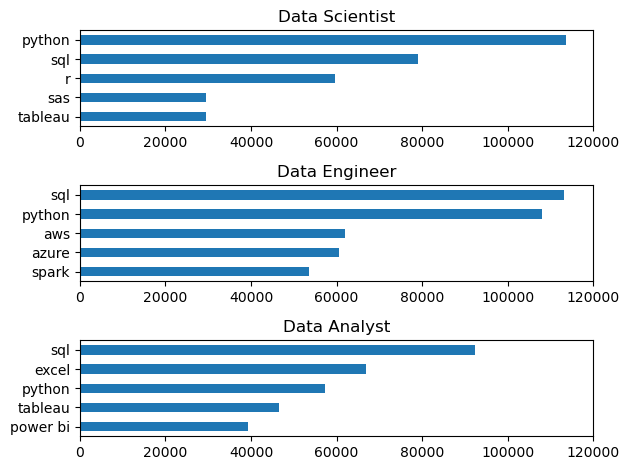

In [60]:
fig, ax = plt.subplots(3,1)
for i,job_title in enumerate(job_titles):
    pivot=df_skills_counts[df_skills_counts['job_title_short']==job_title].head(5)
    pivot.plot(kind='barh',x='job_skills',y='skill_count',ax=ax[i])
    ax[i].set_xlim(0,120000)
    ax[i].set_title(job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().set_visible(False)
fig.tight_layout()